In [1]:
"""
Dependencies
"""
import os
import numpy as np
import cv2
import glob
import random
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.model_selection import KFold

import tensorflow as tf
import tensorflow.keras.backend as K
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.losses import binary_crossentropy

import sys
sys.path.append("/kaggle/input/datasets/quanhh42/multiresunet-models")

from MultiResUnet import *
from Unet import *
from HTSMRUnet import *

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
tf.get_logger().setLevel('ERROR')
print("TensorFlow version:", tf.__version__)
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

2026-05-14 16:31:20.574194: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778776280.769562      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778776280.827026      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778776281.279432      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778776281.279480      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778776281.279483      23 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
Num GPUs Available: 1


In [2]:
"""
Functions & Losses
"""
def jaccard(y_true, y_pred):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f + y_pred_f - y_true_f * y_pred_f)
    return intersection / (union + K.epsilon())
    
def dice_coef(y_true, y_pred):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2.0 * intersection + K.epsilon()) / (K.sum(y_true_f) + K.sum(y_pred_f) + K.epsilon())

def ea_ftl_loss(y_true, y_pred):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    tp = K.sum(y_true_f * y_pred_f)
    fp = K.sum((1.0 - y_true_f) * y_pred_f)
    fn = K.sum(y_true_f * (1.0 - y_pred_f))
    
    alpha_t = 0.3
    beta_t = 0.7
    gamma_t = 4./3.
    
    tversky = (tp + K.epsilon()) / (tp + alpha_t * fp + beta_t * fn + K.epsilon())
    ftl = K.pow((1.0 - tversky), gamma_t)
    
    y_true_edges = tf.image.sobel_edges(y_true)
    y_pred_edges = tf.image.sobel_edges(y_pred)
    edge_loss = K.mean(K.abs(y_true_edges - y_pred_edges))
    
    return ftl + 0.5 * edge_loss

In [3]:
"""
Config & setSeed
"""
class Config:
    width, height = 256, 256
    n_channels = 3
    
    batchSize = 8
    epochs = 150
    lr = 1e-3
    nFolds = 5

    earlyStopping = 150
    seed = 42

    imageDir = "/kaggle/input/datasets/quanhh42/multiresunet-datasets/ISBI2009/images"
    dataColor = "RGB"
    
    maskDir = "/kaggle/input/datasets/quanhh42/multiresunet-datasets/ISBI2009/masks"

    saveDir = "/kaggle/working/ISBI2009-Result"
    

config = Config()

def setSeed(seed):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

setSeed(config.seed)

In [4]:
"""
Load dataset
"""

import re
def extractMainNumber(path):
    name = os.path.splitext(os.path.basename(path))[0]
    nums = re.findall(r'\d+', name)
    if not nums:
        return None
    return nums[-1]

def loadDataset(imageDir, maskDir, height, width, dataColor="RGB"):
    assert dataColor in ["RGB", "BGR", "Grayscale"]

    imagePaths = sorted(glob.glob(os.path.join(imageDir, "*")))
    maskPaths  = sorted(glob.glob(os.path.join(maskDir, "*")))
    maskDict = {extractMainNumber(p): p for p in maskPaths}

    X, Y = [], []

    for imgPath in tqdm(imagePaths):
        name = extractMainNumber(imgPath)
        if name not in maskDict:
            continue

        # image
        if dataColor == "Grayscale":
            img = cv2.imread(imgPath, cv2.IMREAD_GRAYSCALE)
        else:
            img = cv2.imread(imgPath, cv2.IMREAD_COLOR)

        if img is None:
            continue

        if dataColor == "RGB":
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        elif dataColor == "Grayscale":
            img = np.expand_dims(img, -1)

        img = cv2.resize(img, (width, height), interpolation=cv2.INTER_CUBIC)
        img = img.astype(np.float32) / 255.0

        # mask
        mask = cv2.imread(maskDict[name], cv2.IMREAD_GRAYSCALE)
        if mask is None:
            continue

        mask = cv2.resize(mask, (width, height), interpolation=cv2.INTER_NEAREST)
        mask = np.round(mask.astype(np.float32) / 255.0, 0)
        mask = np.expand_dims(mask, -1)

        X.append(img)
        Y.append(mask)

    return np.array(X, dtype=np.float32), np.array(Y, dtype=np.float32)


In [5]:
"""
Model Factory
"""
def buildModel(name, lr, height, width, n_channels, lossFunction, metrics):
    if name == "Unet":
        model = Unet(height = height, width = width, n_channels = n_channels)
    elif name == "MultiResUnet":
        model = MultiResUnet(height = height, width = width, n_channels = n_channels)
    elif name == "HTSMRUnet":
        model = HTSMRUnet(height = height, width = width, n_channels = n_channels)
    else:
        raise Exception("Not a supported model")
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss=lossFunction,
        metrics=metrics
    )

    return model

In [6]:
"""
Run K Fold
"""

def padHistory(values, targetLen):
    if len(values) < targetLen:
        values = values + [values[-1]] * (targetLen - len(values))
    return values

def run_kfold(modelName, lossFunction, config, X, Y, saveName = None):

    if not saveName:
        saveName = modelName
    kf = KFold(n_splits=config.nFolds, shuffle=True, random_state=config.seed)
    os.makedirs(config.saveDir, exist_ok=True)

    results = {
        "model_name": modelName,
        "loss_fn": lossFunction,
        "config": config,
        "save_name": saveName,
        "fold_max_jaccard": [],
        "fold_max_dice": [],
        "histories": [],
    }

    for fold, (train_idx, val_idx) in enumerate(kf.split(X), 1):
        print(f"{modelName} | FOLD {fold}/{config.nFolds}")

        X_train, X_val = X[train_idx], X[val_idx]
        Y_train, Y_val = Y[train_idx], Y[val_idx]

        K.clear_session()

        model = buildModel(
            name = modelName,
            lr = config.lr,
            height = config.height,
            width = config.width,
            n_channels = config.n_channels,
            lossFunction = lossFunction,
            metrics = [jaccard, dice_coef],
        )

        ckpt_path = os.path.join(
            config.saveDir,
            f"{saveName}_fold{fold}.weights.h5"
        )

        checkpoint = ModelCheckpoint(
            ckpt_path,
            monitor = "val_jaccard",
            mode = 'max',
            save_best_only = True,
            save_weights_only = True,
            verbose=0
        )

        earlyStopping = EarlyStopping(
            monitor='val_jaccard',
            mode='max',
            patience=config.earlyStopping,
            restore_best_weights=True,
            verbose=1
        )

        history = model.fit(
            X_train, Y_train,
            validation_data=(X_val, Y_val),
            epochs=config.epochs,
            batch_size=config.batchSize,
            callbacks=[checkpoint, earlyStopping],
            verbose=0
        )

        model.load_weights(ckpt_path)

        val_j = history.history["val_jaccard"]
        val_d = history.history["val_dice_coef"]

        max_j = max(val_j)
        max_d = max(val_d)


        
        results["fold_max_jaccard"].append(max_j)
        results["fold_max_dice"].append(max_d)

        for key, values in history.history.items():
            history.history[key] = padHistory(values, config.epochs)

        results["histories"].append(history)

        print(f"Fold {fold}: Jaccard: {max_j*100:.2f}% | Dice: {max_d*100:.2f}%")


    best_fold = np.argmax(results["fold_max_jaccard"]) + 1
    print("\n\n")
    print(f"{modelName} - K-FOLD DONE - BEST JACCARD FOLD : {best_fold}")
    print("\n\n")

    return results

In [7]:
"""
Show Samples of prediction
"""

def to_rgb_uint8(img):
    img = np.array(img)
    if img.ndim == 4 and img.shape[0] == 1:
        img = img[0]
    if img.dtype != np.uint8:
        img = img.astype(np.float32)
        if img.max() <= 1.0:
            img = img * 255
        elif img.max() <= 255:
            pass
        else:
            img = img / img.max() * 255
        img = img.clip(0, 255).astype(np.uint8)
    if img.ndim == 2:
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    elif img.ndim == 3:
        if img.shape[-1] == 1:
            img = cv2.cvtColor(img.squeeze(-1), cv2.COLOR_GRAY2RGB)
        elif img.shape[-1] == 3:
            pass
        elif img.shape[-1] == 4:  # RGBA
            img = img[..., :3]
        else:
            raise ValueError(f"Unsupported channel: {img.shape}")
    else:
        raise ValueError(f"Unsupported shape: {img.shape}")
    return np.ascontiguousarray(img)

def draw_mask_contour(img_rgb, mask, color, thickness=1):
    mask = np.array(mask)
    if mask.dtype != np.uint8:
        if mask.max() <= 1.0:
            mask_bin = (mask > 0.5).astype(np.uint8)
        else:
            mask_bin = (mask > 127).astype(np.uint8)
    else:
        mask_bin = (mask > 127).astype(np.uint8)
    mask_bin = mask_bin * 255
    contours, _ = cv2.findContours(mask_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    img_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)
    color_bgr = (color[2], color[1], color[0])
    cv2.drawContours(img_bgr, contours, -1, color_bgr, thickness)

    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    
def showVisualComparison(X, Y, bestFoldIdx, resultsList, num_samples=3, saveDir = "/kaggle/working"):
    print("\nVISUALIZING SAMPLE RESULTS")

    num_samples = min(num_samples, len(X))
    preds, names = [], []
    model_dicts = []
    for results in resultsList:
        model_dicts.append(
            {
                "name": results["model_name"],
                "weight": os.path.join(saveDir, f"{results["save_name"]}_fold{bestFoldIdx}.weights.h5"),
                "loss": results["loss_fn"],
                "config": results["config"],
            }
        )
    for m in model_dicts:
        name = m["name"]
        weight_path = m["weight"]
        loss_fn = m["loss"]
        cfg = m["config"]

        K.clear_session()

        model = buildModel(
            name=name,
            lr=cfg.lr,
            height=cfg.height,
            width=cfg.width,
            n_channels=cfg.n_channels,
            lossFunction=loss_fn,
            metrics=[jaccard, dice_coef],
        )

        model.load_weights(weight_path, skip_mismatch=True)

        p = model.predict(X, verbose=0)
        p = (p > 0.5).astype(np.float32)

        preds.append(p)
        names.append(name)

    n_models = len(preds)

    COLOR_GT = (0, 255, 0)
    base_colors = [
        (255, 0, 0),
        (0, 0, 255),
        (255, 255, 0),
        (255, 0, 255),
        (0, 255, 255)
    ]

    for i in range(num_samples):
        n_cols = 3 + n_models
        fig, axes = plt.subplots(1, n_cols, figsize=(5*n_cols, 5))

        img_rgb = to_rgb_uint8(X[i])

        # Input
        axes[0].imshow(img_rgb)
        axes[0].set_title("Input")
        axes[0].axis("off")

        # GT
        axes[1].imshow(Y[i].squeeze(), cmap='gray')
        axes[1].set_title("Ground Truth")
        axes[1].axis("off")

        # Outputs
        for j in range(n_models):
            axes[2+j].imshow(preds[j][i].squeeze(), cmap='gray')
            axes[2+j].set_title(names[j])
            axes[2+j].axis("off")

        # Comparison
        comp = img_rgb.copy()
        comp = draw_mask_contour(comp, Y[i].squeeze(), COLOR_GT)

        patches = [
            mpatches.Patch(color=[c/255 for c in COLOR_GT], label="Ground Truth")
        ]

        for j in range(n_models):
            color = base_colors[j % len(base_colors)]
            comp = draw_mask_contour(comp, preds[j][i].squeeze(), color)

            patches.append(
                mpatches.Patch(color=[c/255 for c in color], label=names[j])
            )

        axes[-1].imshow(comp)
        axes[-1].set_title("Comparison")
        axes[-1].axis("off")
        axes[-1].legend(handles=patches, loc='upper right', fontsize=9)

        plt.tight_layout()
        savePath = os.path.join(
            saveDir,
            f'Demo_Comparison_Overlay_{i+1}.png'
        )
        plt.savefig(savePath, dpi=300)
        plt.show()

In [8]:
"""
Show curves and tables
"""
def showCurves(resultsList, title="Learning Curve", saveDir="/kaggle/working"):
    plt.figure(figsize=(10, 6))

    for results in resultsList:
        name = results.get("save_name", results.get("model_name", "model"))

        curves = []
        for h in results["histories"]:
            if "val_jaccard" in h.history:
                curves.append(h.history["val_jaccard"])

        if len(curves) == 0:
            continue

        min_len = min(len(c) for c in curves)
        curves = np.array([c[:min_len] for c in curves]) * 100

        mean = curves.mean(axis=0)
        std  = curves.std(axis=0)
        x = np.arange(1, len(mean) + 1)

        plt.plot(x, mean, label=name, linewidth=2)
        plt.fill_between(x, mean - std, mean + std, alpha=0.15)

    plt.title(title, fontweight='bold')
    plt.xlabel("Epochs")
    plt.ylabel("Jaccard (%)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()

    savePath = os.path.join(
            saveDir,
            f'Learning_Curves.png'
        )
    plt.savefig(savePath, dpi=300)
    plt.show()

def showTableComparison(resultsList, saveDir="/kaggle/working"):
    base = resultsList[0]
    n_folds = len(base["fold_max_jaccard"])
    base_name = base.get("save_name", base.get("model_name", "model_1"))

    for k in range(1, len(resultsList)):
        other = resultsList[k]
        other_name = other.get("save_name", other.get("model_name", f"model_{k+1}"))

        columns = [
            "Fold",
            f"{base_name}\n(Jaccard / Dice)",
            f"{other_name}\n(Jaccard / Dice)",
            "Comparison\n(+ Jaccard / + Dice)"
        ]

        data = []
        diffs = []

        for i in range(n_folds):
            b_j = base["fold_max_jaccard"][i] * 100
            b_d = base["fold_max_dice"][i] * 100
            o_j = other["fold_max_jaccard"][i] * 100
            o_d = other["fold_max_dice"][i] * 100

            dj, dd = o_j - b_j, o_d - b_d
            diffs.append((dj, dd))

            data.append([
                f"Fold {i+1}",
                f"{b_j:.2f}% / {b_d:.2f}%",
                f"{o_j:.2f}% / {o_d:.2f}%",
                f"{dj:+.2f}% / {dd:+.2f}%"
            ])

        mb_j = np.mean(base["fold_max_jaccard"]) * 100
        mb_d = np.mean(base["fold_max_dice"]) * 100
        mo_j = np.mean(other["fold_max_jaccard"]) * 100
        mo_d = np.mean(other["fold_max_dice"]) * 100
        mdj, mdd = mo_j - mb_j, mo_d - mb_d

        data.append([
            "Mean",
            f"{mb_j:.2f}% / {mb_d:.2f}%",
            f"{mo_j:.2f}% / {mo_d:.2f}%",
            f"{mdj:+.2f}% / {mdd:+.2f}%"
        ])
        diffs.append((mdj, mdd))

        fig, ax = plt.subplots(figsize=(12, 5))
        ax.axis("off")

        table = ax.table(cellText=data, colLabels=columns, loc="center", cellLoc="center")
        table.auto_set_font_size(False)
        table.set_fontsize(11)
        table.scale(1.2, 2.2)

        for (r, c), cell in table.get_celld().items():
            if r == 0:
                cell.set_text_props(weight='bold', color='white')
                cell.set_facecolor('#2E86C1')
            elif r > 0:
                if c == 0:
                    cell.set_text_props(weight='bold')
                if c == 3:
                    dj, dd = diffs[r-1]
                    color = '#27AE60' if (dj >= 0 and dd >= 0) else '#D63230'
                    cell.set_text_props(color=color, weight='bold')
                if r == len(data):
                    cell.set_facecolor('#F4F6F6')
                    cell.set_text_props(weight='bold')

        plt.title(f"{other_name} vs {base_name}", fontweight='bold', pad=15)
        plt.tight_layout()

        savePath = os.path.join(
            saveDir,
            f"{other_name}_vs_{base_name}_Table.png"
        )
        plt.savefig(savePath, dpi=300, bbox_inches='tight')

        plt.show()

In [9]:
X, Y = loadDataset(
    imageDir = config.imageDir,
    maskDir = config.maskDir,
    height = config.height,
    width = config.width,
    dataColor = config.dataColor
)
print(f"X shape: {X.shape}")
print(f"Y shape: {Y.shape}")

100%|██████████| 97/97 [00:04<00:00, 19.47it/s]


X shape: (97, 256, 256, 3)
Y shape: (97, 256, 256, 1)


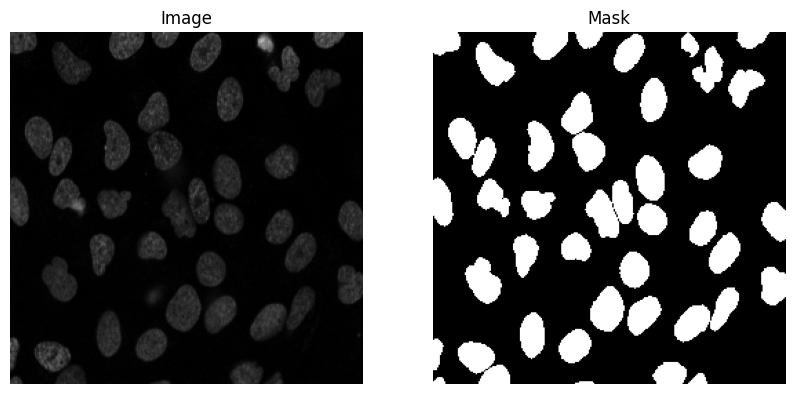

In [10]:
import matplotlib.pyplot as plt

idx = 0

plt.figure(figsize=(10, 5))

# image
plt.subplot(1, 2, 1)
plt.imshow(X[idx])
plt.title("Image")
plt.axis("off")

# mask
plt.subplot(1, 2, 2)
plt.imshow(Y[idx].squeeze(), cmap="gray")
plt.title("Mask")
plt.axis("off")

plt.show()

In [11]:
MultiResUnetResults = run_kfold("MultiResUnet", binary_crossentropy, config, X, Y)
HTSMRUnetResults = run_kfold("HTSMRUnet", ea_ftl_loss, config, X, Y)

MultiResUnet | FOLD 1/5


I0000 00:00:1778776309.732215      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
I0000 00:00:1778776342.988457      75 service.cc:152] XLA service 0x7ab59c0a4960 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778776342.988508      75 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1778776348.295932      75 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1778776389.829702      75 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Restoring model weights from the end of the best epoch: 148.
Fold 1: Jaccard: 90.21% | Dice: 94.83%
MultiResUnet | FOLD 2/5
Restoring model weights from the end of the best epoch: 149.
Fold 2: Jaccard: 89.21% | Dice: 94.26%
MultiResUnet | FOLD 3/5
Restoring model weights from the end of the best epoch: 146.
Fold 3: Jaccard: 91.70% | Dice: 95.66%
MultiResUnet | FOLD 4/5
Restoring model weights from the end of the best epoch: 150.
Fold 4: Jaccard: 89.19% | Dice: 94.26%
MultiResUnet | FOLD 5/5
Restoring model weights from the end of the best epoch: 150.
Fold 5: Jaccard: 88.11% | Dice: 93.67%



MultiResUnet - K-FOLD DONE - BEST JACCARD FOLD : 3



HTSMRUnet | FOLD 1/5
Restoring model weights from the end of the best epoch: 82.
Fold 1: Jaccard: 92.57% | Dice: 96.14%
HTSMRUnet | FOLD 2/5
Restoring model weights from the end of the best epoch: 77.
Fold 2: Jaccard: 89.80% | Dice: 94.59%
HTSMRUnet | FOLD 3/5
Restoring model weights from the end of the best epoch: 87.
Fold 3: Jaccard: 92.79% | 


VISUALIZING SAMPLE RESULTS


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 358 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 442 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


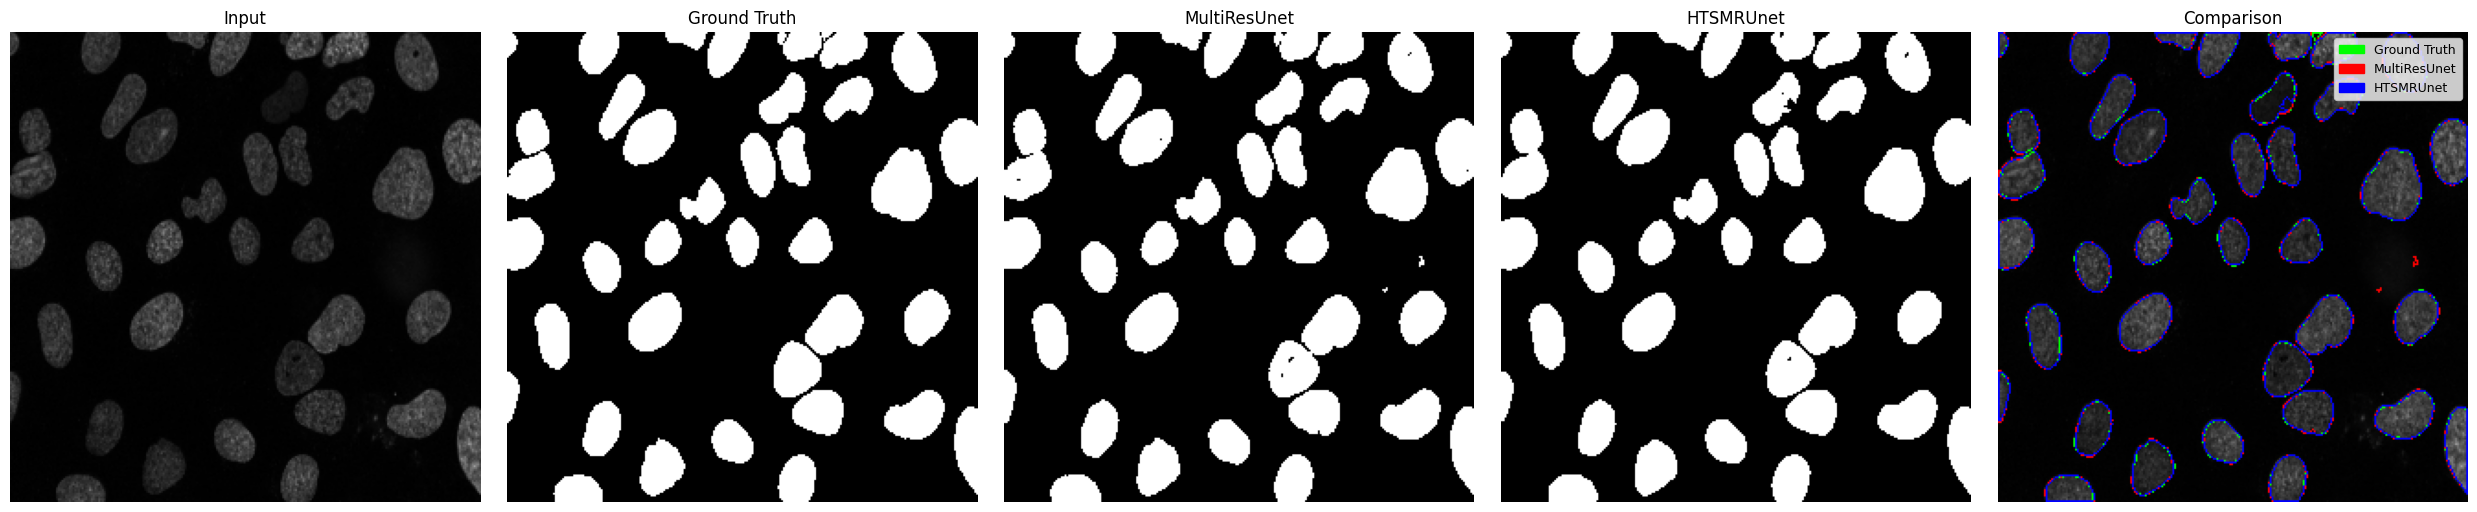

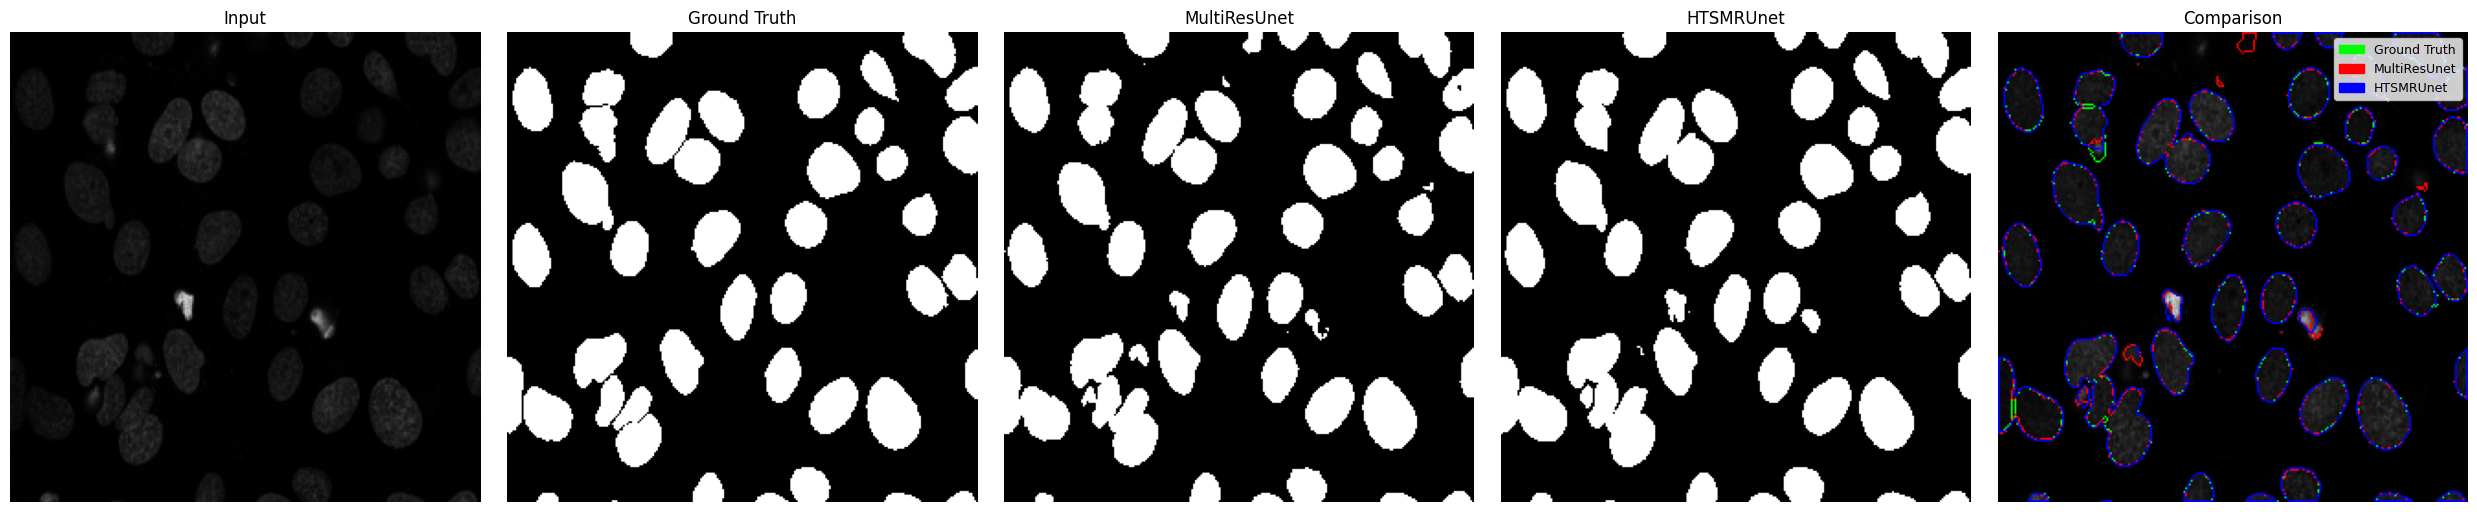

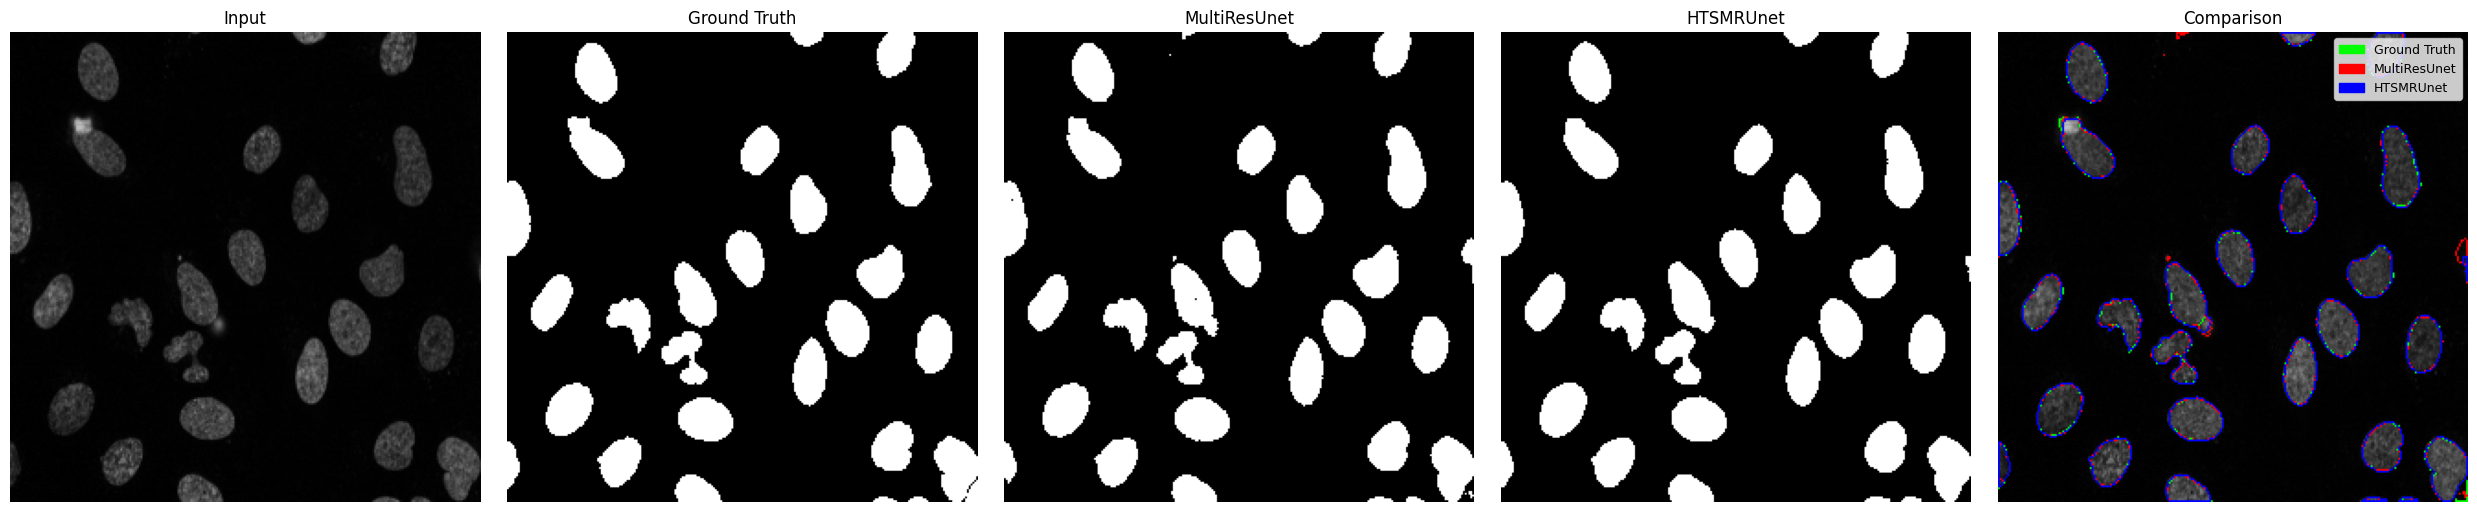

In [12]:
bestFoldIdx = np.argmax(HTSMRUnetResults["fold_max_jaccard"])
kf = KFold(n_splits=config.nFolds, shuffle=True, random_state=config.seed)
train_idx_best, val_idx_best = list(kf.split(X))[bestFoldIdx]
X_val_best = X[val_idx_best]
Y_val_best = Y[val_idx_best]

resultsList = [MultiResUnetResults, HTSMRUnetResults]

showVisualComparison(
    X_val_best,
    Y_val_best,
    bestFoldIdx+1,
    resultsList,
    num_samples = 3,
    saveDir = config.saveDir)

In [13]:
MultiResUnetResults

{'model_name': 'MultiResUnet',
 'loss_fn': <function keras.src.losses.losses.binary_crossentropy(y_true, y_pred, from_logits=False, label_smoothing=0.0, axis=-1)>,
 'config': <__main__.Config at 0x7ab69683e540>,
 'save_name': 'MultiResUnet',
 'fold_max_jaccard': [0.902148425579071,
  0.8921117782592773,
  0.9169996380805969,
  0.8919486999511719,
  0.8811472058296204],
 'fold_max_dice': [0.9483383297920227,
  0.9426015019416809,
  0.9566258788108826,
  0.9426327347755432,
  0.9367482662200928],
 'histories': [<keras.src.callbacks.history.History at 0x7ab68c0634d0>,
  <keras.src.callbacks.history.History at 0x7ab583c21e20>]}

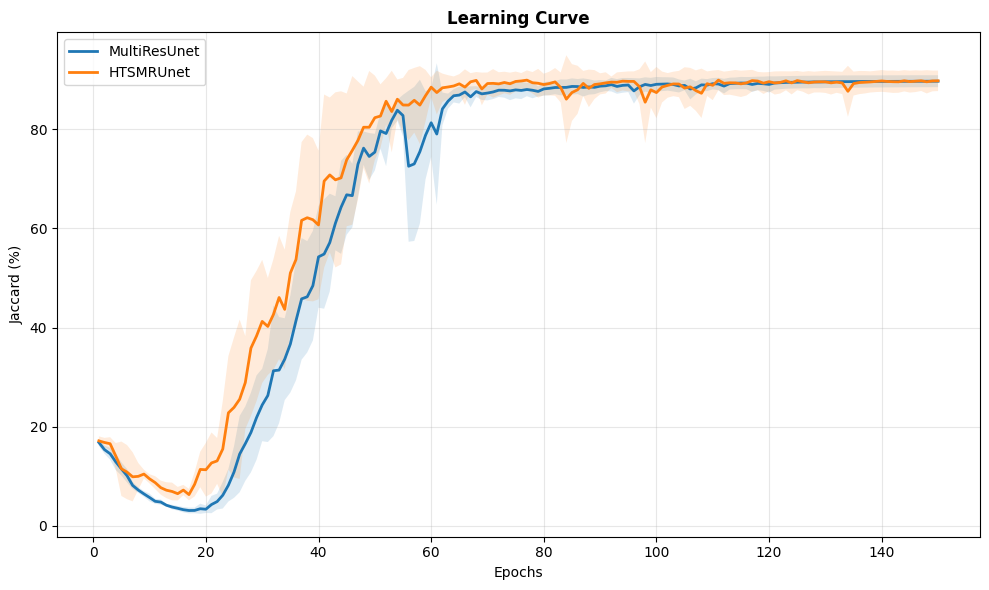

In [14]:
showCurves(resultsList, saveDir = config.saveDir)

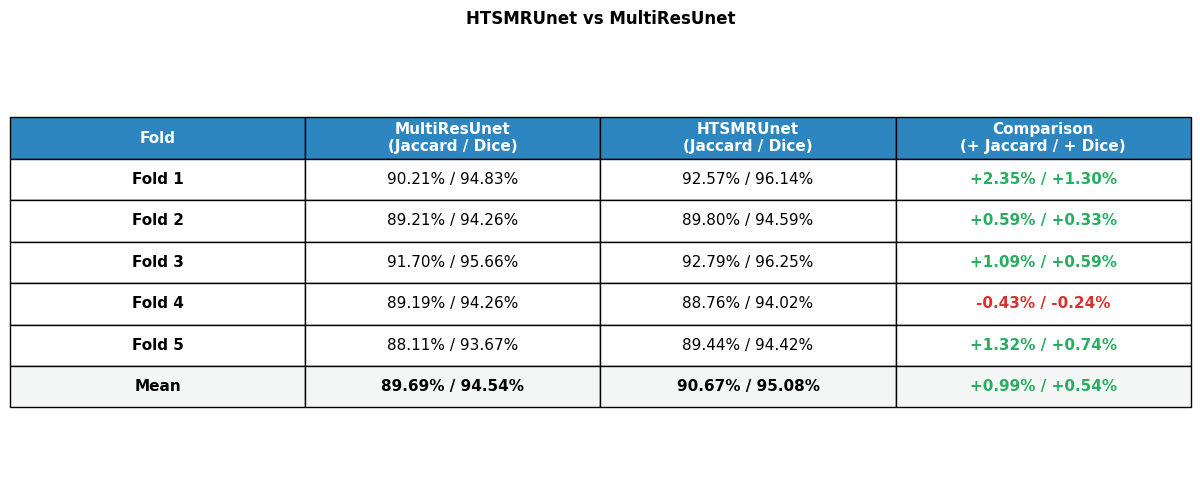

In [15]:
showTableComparison(resultsList, saveDir = config.saveDir)

In [16]:
def saveReports(output_dir, zip_name="report.zip"):
    import zipfile

    with zipfile.ZipFile(zip_name, 'w') as z:
        for root, _, files in os.walk(output_dir):
            for f in files:
                path = os.path.join(root, f)
                z.write(path)

    print(f"Saved report to {zip_name}")

saveReports(config.saveDir, f"{config.saveDir}.zip")

Saved report to /kaggle/working/ISBI2009-Result.zip
